## STEP 1: BUSINESS UNDERSTANDING

We are working on the Diabetes Readmission Prediction project. The primary goal is to predict whether a patient with diabetes will be readmitted to the hospital. This is crucial for healthcare providers to improve patient care, reduce healthcare costs, and optimize resource allocation.

From a data scientist's perspective, many columns are important as they provide information about the patient's demographics, medical history, treatments, and hospital stay. Some of the key categories of columns include:

Demographics: race, gender, age (these can influence health outcomes).
Admission/Discharge Information: admission_type_id, discharge_disposition_id, admission_source_id (provide context about the hospital visit).
Medical History/Procedures: time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_outpatient, number_emergency, number_inpatient, number_diagnoses, diag_1, diag_2, diag_3 (detailed patient health and treatment information).
Medication Information: Columns related to specific diabetes medications like metformin, insulin, glipizide, etc., and change, diabetesMed (critical for understanding treatment efficacy and patient adherence).
Target Variable: readmitted (this is what we are trying to predict, indicating whether the patient was readmitted within 30 days, after 30 days, or not at all).



## STEP 2: DATA COLLECTION

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Download the dataset
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch diabetes dataset
diabetes = fetch_ucirepo(id=296)

# store as dataframe
df = diabetes.data.features
df['readmitted'] = diabetes.data.targets

# check the shape
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (101766, 48)

First 5 rows:


/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)
/tmp/ipykernel_3249/3301551677.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['readmitted'] = diabetes.data.targets


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# see last 5 rows
df.tail()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,NaN,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,NaN,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,Caucasian,Male,[70-80),NaN,1,1,7,6,NaN,NaN,...,No,No,No,No,No,No,No,No,No,NO


In [ ]:
# lets have the Dtype about this data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [ ]:
df.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [ ]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"\nTotal Patients: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")

print("\n" + "=" * 50)
print("COLUMN NAMES")
print("=" * 50)
print(df.columns.tolist())

print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

DATASET OVERVIEW

Total Patients: 101,766
Total Features: 48

COLUMN NAMES
['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

DATA TYPES
race                        object
gender                      object
age                         object
weight               

### INSIGHT
* There are some serious missing values in the data.
* Weight has almost the entire information lost. 98,569 missing
* medical_speciality has 49,949 missing data
* max_glu_serum also has 96,420 data missing in that column
* A1Cresult has 84,748 missing values
* payer_code has 40,256 missing values
* race has 2,273 has missing values
* Even though the dataset is big, there are alot missing values in some columns

## STEP 3: DATA CLEANING

In [ ]:

# Drop columns with too many missing values (>50% missing)
df = df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult', 'payer_code'])

# Fill missing 'race' with mode (most frequent value)
df['race'] = df['race'].fillna(df['race'].mode()[0])
df['diag_1'] = df['diag_1'].fillna(df['diag_1'].mode()[0])
df['diag_2'] = df['diag_2'].fillna(df['diag_2'].mode()[0])
df['diag_3'] = df['diag_3'].fillna(df['diag_3'].mode()[0])

# Fill missing 'medical_specialty' with 'Unknown'
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')

# Verify no more missing values
print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nShape after cleaning:", df.shape)
print("\nCleaning Complete! ✅")

Missing values after cleaning:
Series([], dtype: int64)

Shape after cleaning: (101766, 44)

Cleaning Complete! ✅


#### Prepare the target variable

In [ ]:
# The target column is 'readmitted' with values: 'NO', '<30', '>30'
print(df['readmitted'].value_counts())

# Convert to binary: 1 if readmitted within 30 days, else 0
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print("\nNew target distribution:")
print(df['readmitted_binary'].value_counts())
print(df['readmitted_binary'].value_counts(normalize=True))

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

New target distribution:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64
readmitted_binary
0    0.888401
1    0.111599
Name: proportion, dtype: float64


#### INSIGHT
* Out of the 101766 patients, only 11357 patients have the possibility of being readmitted to the hospital.
* The remaining 90409 have less or no possibility within the first 30 days

## STEP 4: EXPLORATORY DATA ANALYSIS (EDA)

#### We need to understand distributions, relationships and patterns of the dataset

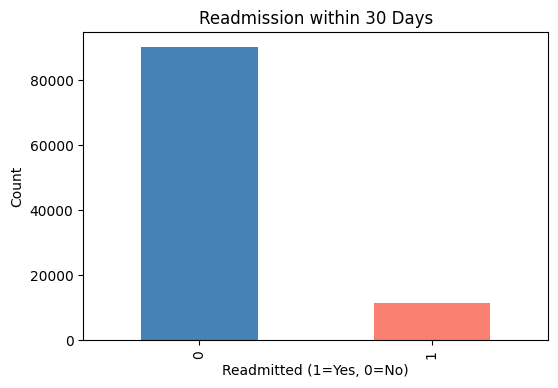

In [ ]:
# Overall readmission rate
plt.figure(figsize=(6,4))
df['readmitted_binary'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Readmission within 30 Days')
plt.xlabel('Readmitted (1=Yes, 0=No)')
plt.ylabel('Count')
plt.show()

#### Readmission Rate by Gender

/tmp/ipykernel_3249/1436883433.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender', y='readmitted_binary', data=gender_readmission, palette='viridis')


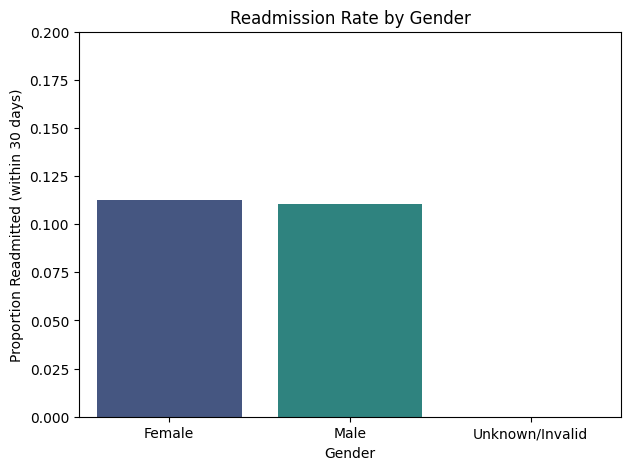

In [ ]:
gender_readmission = df.groupby('gender')['readmitted_binary'].mean().reset_index()
plt.figure(figsize=(7, 5))
sns.barplot(x='gender', y='readmitted_binary', data=gender_readmission, palette='viridis')
plt.title('Readmission Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Proportion Readmitted (within 30 days)')
plt.ylim(0, 0.2) # Set y-axis limit to better compare small proportions
plt.show()

#### Readmission Rate by Race

/tmp/ipykernel_3249/1096995024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='race', y='readmitted_binary', data=race_readmission, palette='magma')


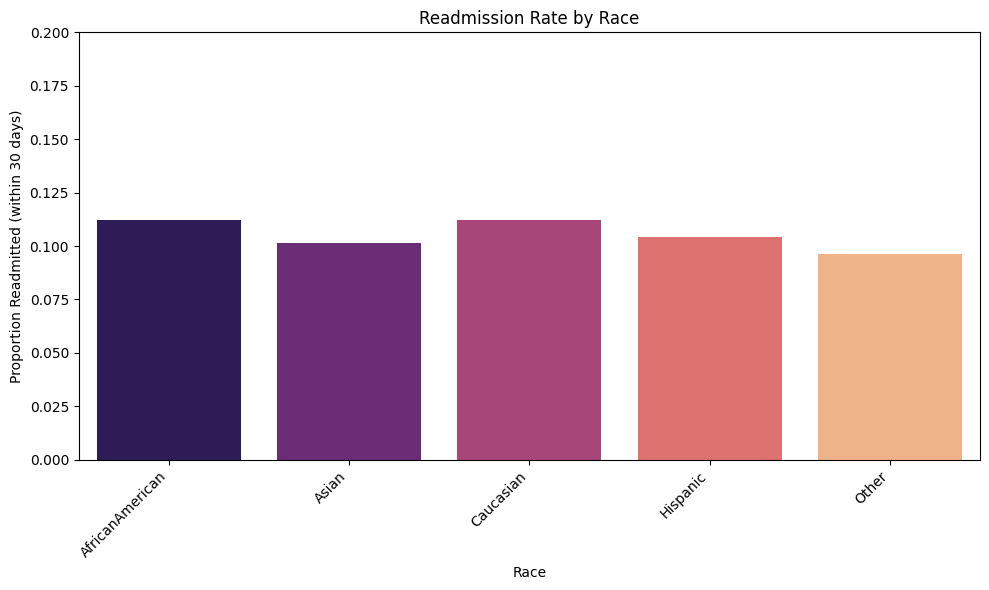

In [ ]:
race_readmission = df.groupby('race')['readmitted_binary'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='race', y='readmitted_binary', data=race_readmission, palette='magma')
plt.title('Readmission Rate by Race')
plt.xlabel('Race')
plt.ylabel('Proportion Readmitted (within 30 days)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 0.2)
plt.tight_layout()
plt.show()

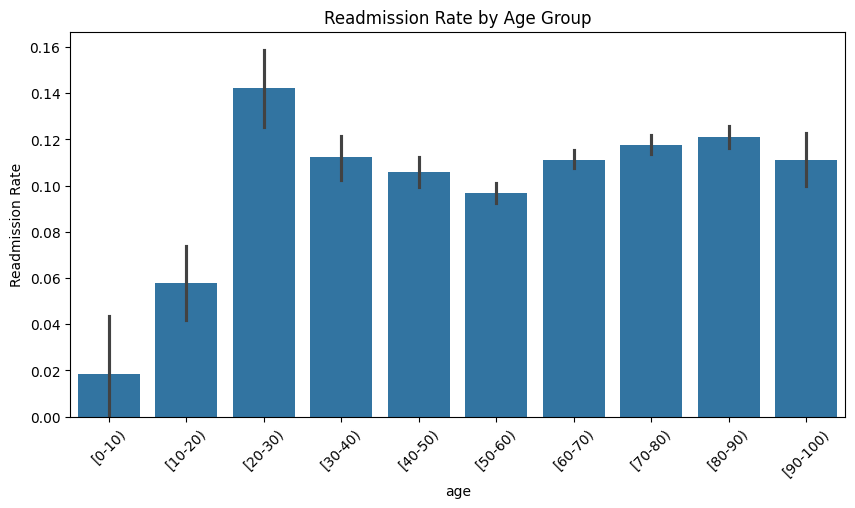

In [ ]:
# Readmission by age group
plt.figure(figsize=(10,5))
sns.barplot(x='age', y='readmitted_binary', data=df, order=sorted(df['age'].unique()))
plt.title('Readmission Rate by Age Group')
plt.xticks(rotation=45)
plt.ylabel('Readmission Rate')
plt.show()

#### Lets probe more into the readmission rate to know why age 20-30 has high rate.

- we will use medication usage as a proxy since we don't have a direct diabetes type column.
- All Type 1 diabetics require insulin and many Type 2 diabetics also eventually use it.

### Insulin Usage by Age Group

<Figure size 1200x700 with 0 Axes>

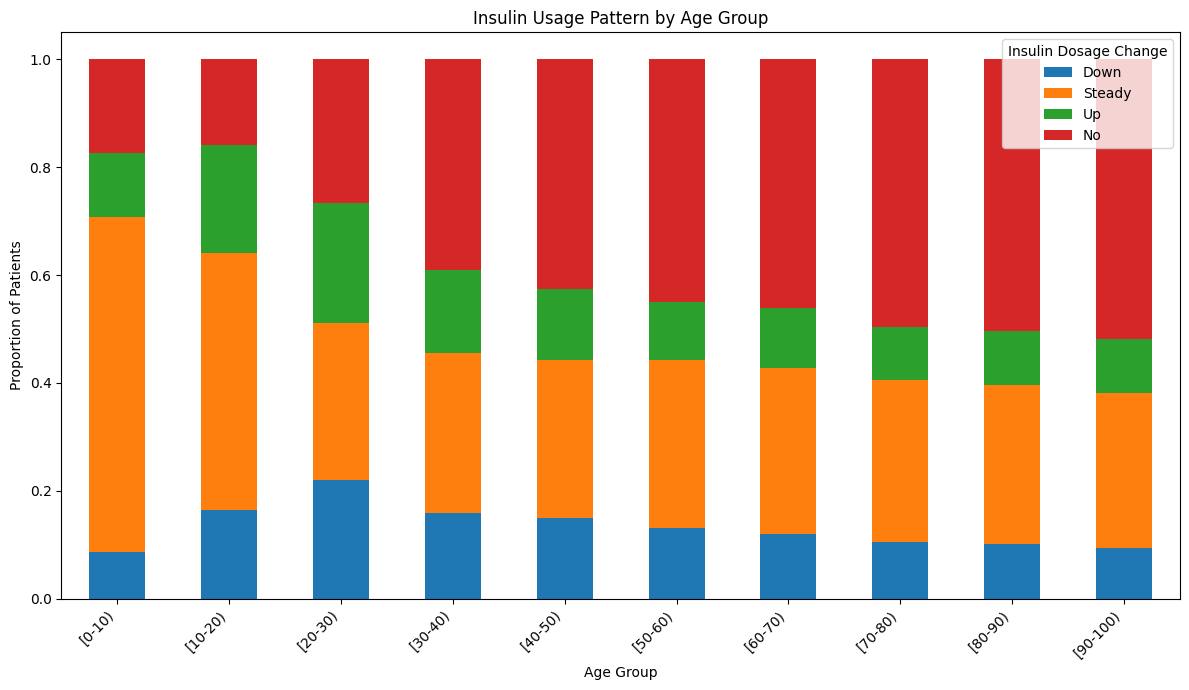

In [ ]:
insulin_usage_age = df.groupby(['age', 'insulin'])['readmitted_binary'].count().unstack(fill_value=0)
insulin_usage_age['Total'] = insulin_usage_age.sum(axis=1)
insulin_usage_age_proportion = insulin_usage_age.div(insulin_usage_age['Total'], axis=0)

# Sort by age group for better visualization
age_order = sorted(df['age'].unique())
insulin_usage_age_proportion = insulin_usage_age_proportion.reindex(age_order)

plt.figure(figsize=(12, 7))
insulin_usage_age_proportion[['Down', 'Steady', 'Up', 'No']].plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Insulin Usage Pattern by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Patients')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Insulin Dosage Change')
plt.tight_layout()
plt.show()

#### INSIGHT
 - Younger Age Groups (0-10, 10-20, 20-30): We see a relatively high proportion of 'Up' and 'Steady' insulin usage, and a lower proportion of 'No' insulin usage compared to older age groups. This pattern is often associated with Type 1 Diabetes, where patients are insulin dependent from a young age and often require adjustments ('Up' or 'Down') in their dosage.

 - Older Age Groups: As age increases, the proportion of patients not on insulin ('No') generally rises. This could indicate a higher prevalence of Type 2 Diabetes that is managed with oral medications or lifestyle changes, or Type 1 Diabetes that has been stable for a long time. However, even in older groups, a significant portion are on 'Steady' or 'Up' insulin, which could be Type 2 Diabetes progressing to insulin dependency.

#### Insulin Impact on Readmission by Age Group

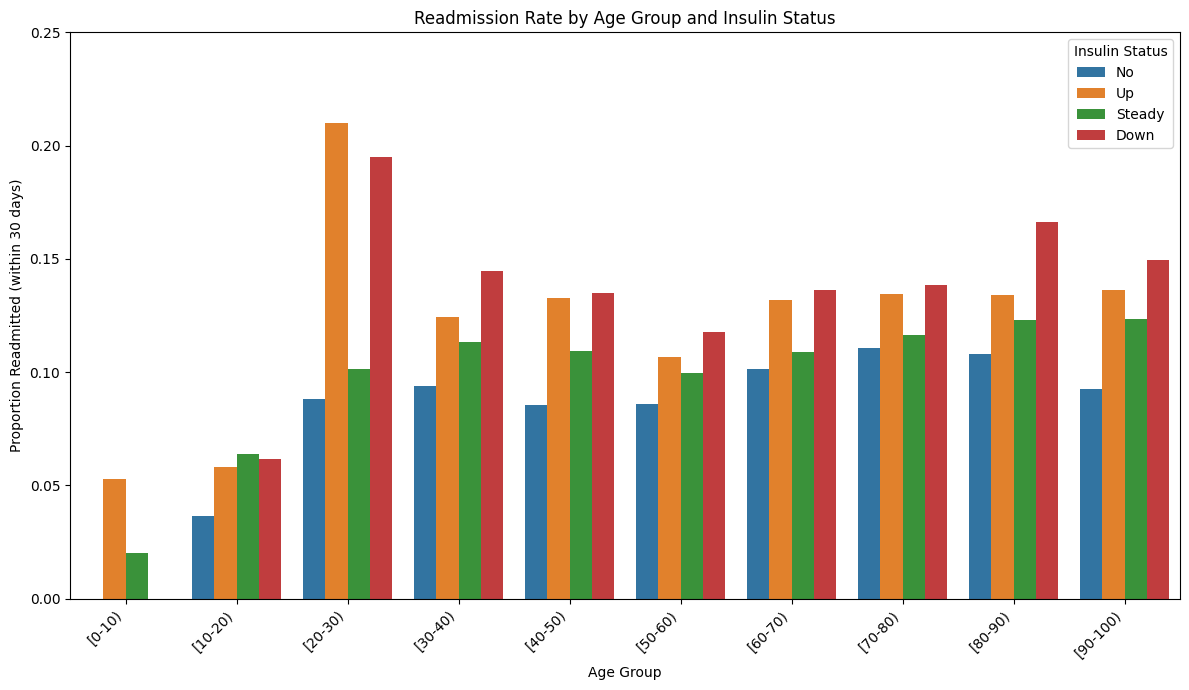

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='age', y='readmitted_binary', hue='insulin', data=df, errorbar=None, order=sorted(df['age'].unique()))
plt.title('Readmission Rate by Age Group and Insulin Status')
plt.xlabel('Age Group')
plt.ylabel('Proportion Readmitted (within 30 days)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Insulin Status')
plt.ylim(0, 0.25) # Adjust y-limit for better visual comparison
plt.tight_layout()
plt.show()

- 20-30 Age Group Highlight: Notice that within the 20-30 age group, the patients who are on 'Up' insulin show a significantly higher readmission rate compared to other insulin statuses in that same age group, and also compared to most other age insulin combinations. Patients with insulin status 'Steady' or 'Down' in this age group also have elevated readmission rates compared to those on 'No' insulin.

- General Trend: Across most age groups, patients with 'Up' or 'Steady' insulin tend to have higher readmission rates than those with 'No' insulin. This suggests that patients requiring more active insulin management (either due to new onset, worsening condition, or dose adjustment) are at a higher risk of readmission. While we don't have direct labels for Type 1 vs. Type 2 diabetes, these plots provide strong correlational evidence. Higher Insulin Dependency in younger Ages and The 'Readmission Rate' plot reinforces this. The very high readmission rate for the 20-30 age group is particularly driven by individuals on 'Up' insulin. The 'Readmission Rate' plot reinforces this. The very high readmission rate for the 20-30 age group is particularly driven by individuals on 'Up' insulin.

I have completed the analysis of insulin usage and its impact on readmission rates across different age groups, providing insights that suggest a connection to diabetes types, particularly in younger populations.

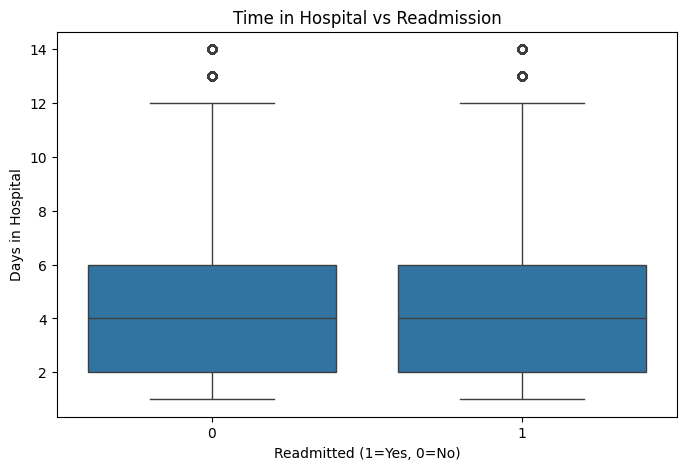

In [ ]:
# Readmission by time in hospital
plt.figure(figsize=(8,5))
sns.boxplot(x='readmitted_binary', y='time_in_hospital', data=df)
plt.title('Time in Hospital vs Readmission')
plt.xlabel('Readmitted (1=Yes, 0=No)')
plt.ylabel('Days in Hospital')
plt.show()

#### INSIGHT
It appears there isn't a significant difference in the median time_in_hospital between patients who were readmitted and those who were not. Both groups show similar distributions, with medians around 4 days and interquartile ranges (IQR) of about 2 to 6 days. This suggests that simply staying longer or shorter in the hospital during the initial admission doesn't, on its own, strongly predict readmission within 30 days.

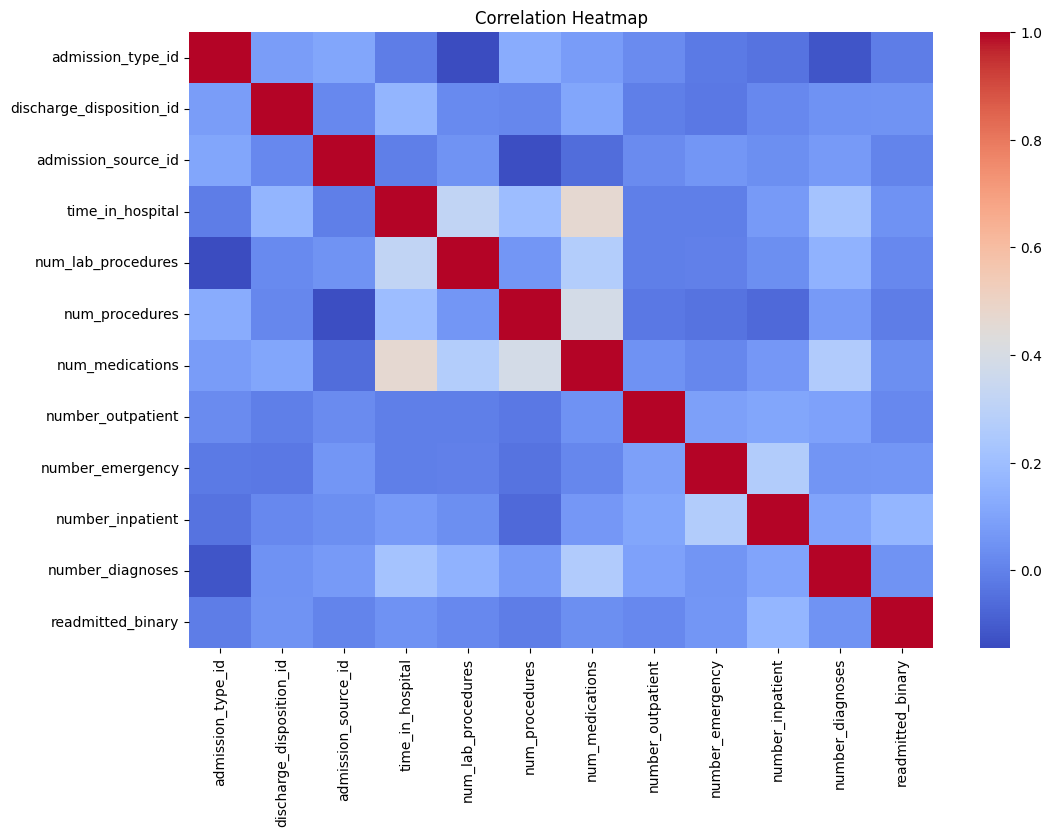

In [ ]:
# Correlation heatmap of numeric features
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

 #### INSIGHT
 We can observe moderate positive correlations between time_in_hospital, num_lab_procedures, num_medications, and number_diagnoses, suggesting that patients with longer stays, more lab tests, or more medications often have a higher number of diagnoses. Interestingly, the readmitted_binary variable (our target) shows very weak correlations with most other numeric features, indicating that individual numerical features alone are not strong linear predictors of readmission in this dataset.

In [ ]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_binary
0,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,0,...,No,No,No,No,No,No,No,No,NO,0
1,Caucasian,Female,[10-20),1,1,7,3,Unknown,59,0,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,11,5,...,No,No,No,No,No,No,No,Yes,NO,0
3,Caucasian,Male,[30-40),1,1,7,2,Unknown,44,1,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,Caucasian,Male,[40-50),1,1,7,1,Unknown,51,0,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


## STEP 5: FEATURE ENGINEERING AND PREPROCESSING

Now that the missing values have been handled, we need to preprocess the data further for model training. This includes:

1.  **Handling Categorical Variables**: Many columns are of `object` type (categorical). We need to convert these into a numerical format that machine learning models can understand. This can be done using techniques like one-hot encoding or label encoding.
2.  **Scaling Numerical Features**: Although there are no obvious numerical features that require scaling at first glance, it's a common practice if numerical features have vastly different ranges or distributions, which can impact the performance of some models.

In [ ]:
# We drop readmitted since we have engineered readmitted_binary
df_model = df.drop(columns=('readmitted'))

print(df_model.shape)
print(df_model.dtypes.value_counts())

(101766, 44)
object    32
int64     12
Name: count, dtype: int64


#### We will create a 'total visit' feature

In [ ]:
# Combine prior outpatient, emergency, and inpatient visits into one feature
df_model['total_prior_visits'] = (
df_model['number_outpatient'] +
df_model['number_emergency'] +
df_model['number_inpatient']
)

print(df_model[['number_outpatient','number_emergency','number_inpatient','total_prior_visits']].head())

   number_outpatient  number_emergency  number_inpatient  total_prior_visits
0                  0                 0                 0                   0
1                  0                 0                 0                   0
2                  2                 0                 1                   3
3                  0                 0                 0                   0
4                  0                 0                 0                   0


#### Now we will encode Categorical Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical (object) columns
cat_cols = df_model.select_dtypes(include='object').columns
print("Categorical columns to encode:", list(cat_cols))

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("\nAll columns now numeric:", df_model.dtypes.value_counts())

Categorical columns to encode: ['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

All columns now numeric: int64    45
Name: count, dtype: int64


### Train/ Test Split

* I will be seperating df_model into two things. X and Y
X will be all the input columns except the target and
Y will be the target column(readmitted_binary) which.

* I will apply the stratify becuase our dataset is inbalance (89% / 11%) if I randomly split, by chance, the test set could end up with say, 5% readmitted cases instead of 11% .

* I will again set a seed number for the shuffle so that when rerunning the cell, I get the exact same split everytime.(random_state = 42)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['readmitted_binary'])
y = df_model['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.25,
random_state=42,
stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining set target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest set target distribution:")
print(y_test.value_counts(normalize=True))

Training set size: (76324, 44)
Test set size: (25442, 44)

Training set target distribution:
readmitted_binary
0    0.888397
1    0.111603
Name: proportion, dtype: float64

Test set target distribution:
readmitted_binary
0    0.888413
1    0.111587
Name: proportion, dtype: float64


#### INSIGHT
* Training set has 76,324 rows and Test set has 25,442 rows which is perfect.
* Our Stratify also worked perfectly. Training has 88.8% not admitted and 11.2% readmitted whiles Test has 88.8% not readmitted, 11.2% readmitted
* Both sets have almost identical proportions. The inbalance is preserved equally in both which is what we want.

## STEP 6: MODEL BUILDING

* Here I will use the .fit_transform to train the model for patterns. The agorithm is adjusted wil adjust it internal math repeatedly until it gets good at predicting the known outcomes.
* I will use Logistic Regression for the baseline because it is simple, fast, interpretable and gives us the minimum bar.
* I will also use Scaling

In [ ]:
# Scale the features (important for Logistic Regression)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete ✅")
print("X_train_scaled shape:", X_train_scaled.shape)

Scaling complete ✅
X_train_scaled shape: (76324, 44)


In [ ]:
from sklearn.linear_model import LogisticRegression

# THIS IS OUR BASELINE MODEL
baseline_model = LogisticRegression(max_iter=1000,
class_weight='balanced',
random_state=42)

baseline_model.fit(X_train_scaled, y_train)

print("Baseline Logistic Regression trained ✅")

Baseline Logistic Regression trained ✅


#### INSIGHT
* Baseline is built and ready

## STEP 7: MODEL EVALUATION

BASELINE MODEL - LOGISTIC REGRESSION

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     22603
           1       0.17      0.51      0.26      2839

    accuracy                           0.67     25442
   macro avg       0.54      0.60      0.52     25442
weighted avg       0.83      0.67      0.73     25442

ROC-AUC Score: 0.645


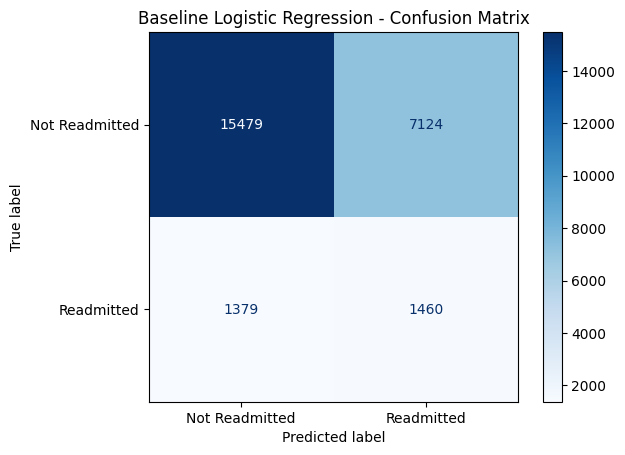

In [ ]:
from sklearn.metrics import (classification_report,
confusion_matrix,
roc_auc_score,
ConfusionMatrixDisplay)

# Generate predictions on the test set
y_pred_baseline = baseline_model.predict(X_test_scaled)
y_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Print all evaluation metrics
print("=" * 50)
print("BASELINE MODEL - LOGISTIC REGRESSION")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_baseline), 4))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
display_labels=['Not Readmitted','Readmitted'])
disp.plot(cmap='Blues')
plt.title('Baseline Logistic Regression - Confusion Matrix')
plt.show()


#### INSIGHT
* From the confusion matrix, 15479 patients were correctly flagged as "not readmitted" True Positive
* 7124 patients were wrongly flagged as 'readmited" when they were not. False Negative
* 1379 patients were "readmitted" but the model said they were not. False Positive
* 1460 patients were admitted and the model predicted as correct.
* Class 0 =(Not Readmitted): Precision 0.92, recall 0.68
* Class 1 =(Readmitted): Precision 0.17, recall 0.51
* The model catches about 51% of true readmission(recall for class 1) which is better than a coin flip.
* Precision flagged 0.17 which is alarming because it means that for every 100 patients we flag as "high risk of readmission," only 17 actually get readmitted. that is a lot of "False Alarrm". It means the hospital waste a lot of follow up calls/ resources on patients who didn't need it.
* ROC-AUC = 0.645 means the model has learned something real, but it is a fairly weak signal which confirms our correlation heatmap that most numeric features showed weak linear correlation with the target.

#### Let's build Random Forest and see if it beats the baseline

In [ ]:
# First we train the model
from sklearn.ensemble import RandomForestClassifier

# Random Forest doesn't need scaled data - it splits on raw values
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained ✅")

Random Forest trained ✅


RANDOM FOREST MODEL

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     22603
           1       0.74      0.01      0.01      2839

    accuracy                           0.89     25442
   macro avg       0.81      0.50      0.48     25442
weighted avg       0.87      0.89      0.84     25442

ROC-AUC Score: 0.6522


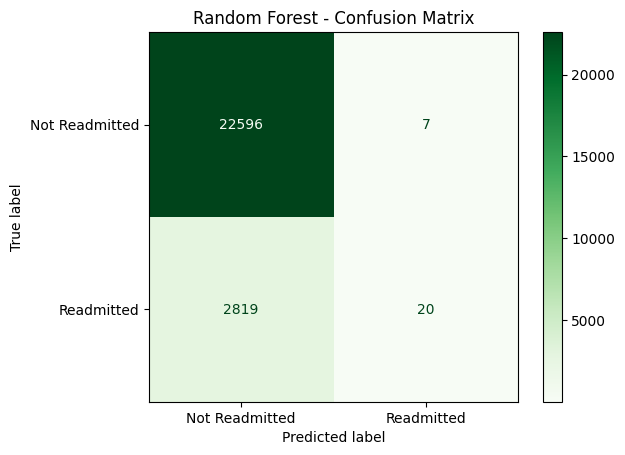

In [ ]:
# Now lets trained model on the test data(raw 25%)
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score,
                              ConfusionMatrixDisplay)

# Generate predictions on the SAME test set used for the baseline
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST MODEL")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_rf), 4))

# Plot confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['Not Readmitted','Readmitted'])
disp.plot(cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.show()

#### INSIGHT
* 22596 Patients were not readmitted which is True Negative
* 7 Patients actually were not readmitted but model predicted readmitted which is False Positive
* 2819 Patients were actually readmitted but model predicted not readmitted which is False Negative(dangerous miss)
* 20 Patients were actually readmitted and model predicted readmitted which is True Positive
* Random Forest's recall for class 1 collapse to 0.01. it almost never predict "readmitted" at all compare to the baseline's recall of 0.51.
* Accuracy went up to 89% and ROC-AUC barely moved
* From this the model is useless for our actual goal of catching readmissions.

#### I will fix this by troubleshotting between this options:
1. Adjusting the decision threshold or
2. use class_weight =. balance_subsample or
3. use actual resampling(SMOTE)
I will try the first option first

RANDOM FOREST - Adjusted Threshold (0.2)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     22603
           1       0.26      0.21      0.23      2839

    accuracy                           0.84     25442
   macro avg       0.58      0.57      0.57     25442
weighted avg       0.83      0.84      0.84     25442

ROC-AUC Score (unchanged, threshold-independent): 0.6522


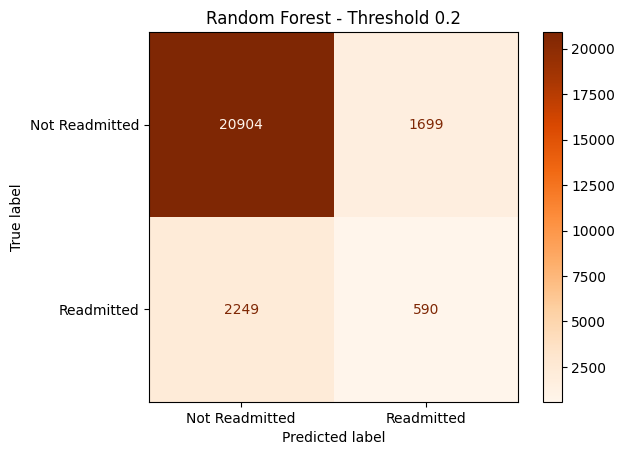

In [ ]:
# Try a lower threshold instead of the default 0.5
threshold = 0.2

y_pred_rf_adjusted = (y_prob_rf >= threshold).astype(int)

print("=" * 50)
print(f"RANDOM FOREST - Adjusted Threshold ({threshold})")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_adjusted))
print("ROC-AUC Score (unchanged, threshold-independent):", round(roc_auc_score(y_test, y_prob_rf), 4))

cm_adj = confusion_matrix(y_test, y_pred_rf_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_adj,
                               display_labels=['Not Readmitted','Readmitted'])
disp.plot(cmap='Oranges')
plt.title(f'Random Forest - Threshold {threshold}')
plt.show()

#### INSIGHT
* Even after dropping the threshold to 0.2, recall on the readmitted class is only 0.21 to precision 0.26. F1 IS 0.23
* So this will not help

              precision    recall  f1-score   support

           0       0.90      0.93      0.91     22603
           1       0.26      0.21      0.23      2839

    accuracy                           0.85     25442
   macro avg       0.58      0.57      0.57     25442
weighted avg       0.83      0.85      0.84     25442

ROC-AUC Score: 0.6527


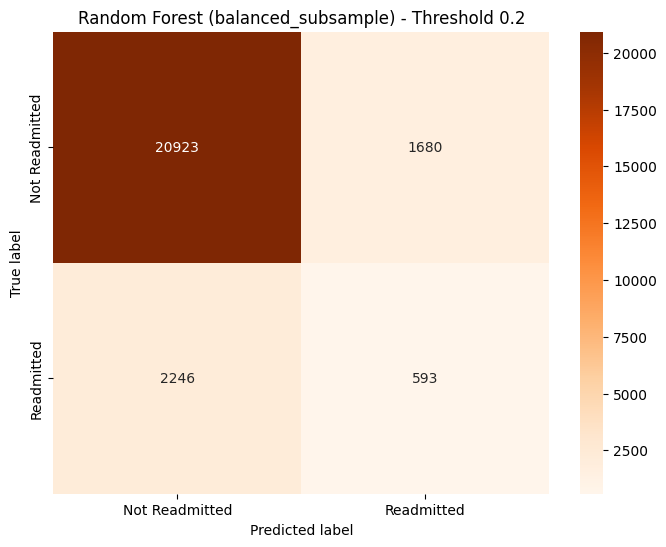

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Option 2: balanced_subsample instead of balanced (or no weighting)
rf_subsample = RandomForestClassifier(
    n_estimators=200,          # match whatever your original RF used
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_subsample.fit(X_train, y_train)

# Probabilities for the positive (readmitted) class
y_proba = rf_subsample.predict_proba(X_test)[:, 1]

# Same threshold (0.2) you already tested, for apples-to-apples comparison
threshold = 0.2
y_pred = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Random Forest (balanced_subsample) - Threshold 0.2')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

#### INSIGHT
Confirmed basically no change ROC-AUC went from 0.6522 to 0.6527 and the recall on the readmitted class stayed flat at 0.21. So we can confrim thta balances_subsample only changes how losses are weighted internally per tree but it doesn't change what data the model actually sees. Two different weighting scheme landing in the same palce is a strong signal that the bottlenect is not the weighting math at all.

#### Let's use the SMOTE and SMOTENC


Before: {0: 67806, 1: 8518}
After:  {0: 67806, 1: 67806}
              precision    recall  f1-score   support

           0       0.92      0.46      0.61     22603
           1       0.14      0.69      0.23      2839

    accuracy                           0.48     25442
   macro avg       0.53      0.57      0.42     25442
weighted avg       0.83      0.48      0.57     25442

ROC-AUC Score: 0.6000


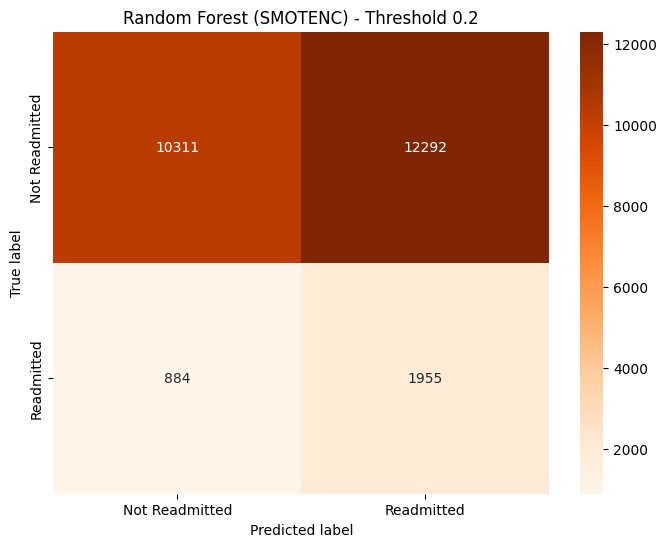

In [ ]:

from imblearn.over_sampling import SMOTENC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric count features — verify these match your actual engineered columns
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                 'num_medications', 'number_outpatient', 'number_emergency',
                 'number_inpatient', 'number_diagnoses']

categorical_cols = [c for c in X_train.columns if c not in numeric_cols]
categorical_indices = [X_train.columns.get_loc(c) for c in categorical_cols]

# Apply SMOTENC to TRAINING data only — never touch X_test
smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_train_res, y_train_res = smote_nc.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts().to_dict())
print("After: ", y_train_res.value_counts().to_dict())

# No class_weight needed now — the training data itself is balanced
rf_smote = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_res, y_train_res)

# Evaluate on the original, untouched test set
y_proba = rf_smote.predict_proba(X_test)[:, 1]
threshold = 0.2
y_pred = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Random Forest (SMOTENC) - Threshold 0.2')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

#### INSIGHT
* We can see Precision dropped to 0.14, accuracy dropped to 0.48 and most importantly for the first time, ROC-AUC dropped from 0.65 to 0.60. That is important not just the jump for recall to 0.69.
* SMOTENC is the most aggressive intervention , why? because it didn't improve it, it sightly hurt it.
Three different imbalance handling techniques converging on the same ceiling is a strong signal that imbalance is not actually the limiting factor anymore but the features ability to seperate the classes in the first palce.

#### INSIGHT
All 3 different imbalance technique have all converge on roughly the same 0.60-0.65 ROC-AUC ceiling. That is a strong signal that imbalance correction has run its course as a lever of this project.
* At this point, I will switch to a model that can extract more signal from the same features.
* I will use XGBoost which mostly outperforms Random Forest on this kind of structure.

#### Lets check the 0.5 threshold again

In [ ]:
y_pred_default = (y_proba >= 0.5).astype(int)
print(classification_report(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90     22603
           1       0.17      0.15      0.16      2839

    accuracy                           0.82     25442
   macro avg       0.53      0.53      0.53     25442
weighted avg       0.81      0.82      0.82     25442



#### INSIGHT
sisde by side
* Threshold tunning alone (0.2) : recall 0.21, ROC-AUC 0.65
* Balanced_subsample(0.2): recall 0.21, ROC-AUC 0.65
* SMOTENC natural threshold (0.5) : recall 0.15, ROC-AUC 0.60.
* Three different imbalance corrections, three flat results.

#### XGBOOST

scale_pos_weight: 7.96
ROC-AUC Score: 0.6839
              precision    recall  f1-score   support

           0       0.93      0.66      0.77     22603
           1       0.18      0.61      0.28      2839

    accuracy                           0.65     25442
   macro avg       0.56      0.64      0.53     25442
weighted avg       0.85      0.65      0.72     25442



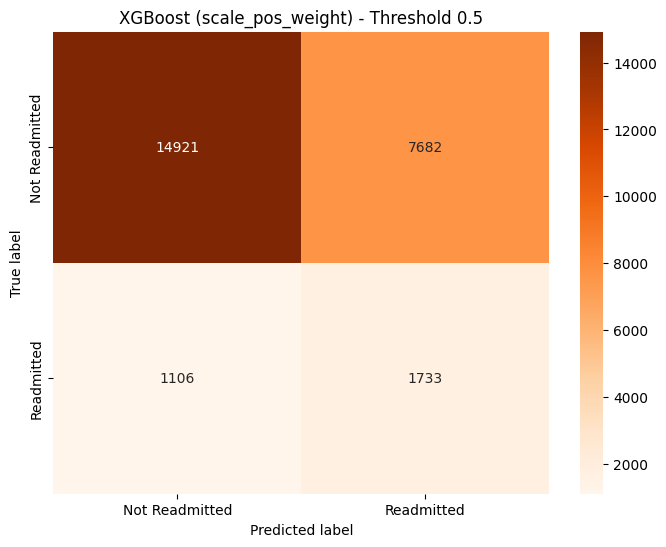

In [ ]:

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Use the ORIGINAL training data — not the SMOTENC-resampled version
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('XGBoost (scale_pos_weight) - Threshold 0.5')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

### INSIGHT
* XGBoost broke through. ROC-AUC of 0.684 clears every previous model LR's 0.645 and RF's best of 0.653 and recall on readmitted patients hit 0.61, the strongest result gotten without sacrificing accuracy the way SMOTENC did
* Compare it to LR fairly. Recall jumped from 0.51 to 0.61 while ROC-AUC also improved (0.645 → 0.684) so this isn't a threshold artifact like the SMOTENC trap. Both the ranking ability and the practical recall improved together, which is the real signal that I want.
* From the 5 approaches tested, XGBoost is the only one that broke the  0.60 - 0.65 ceiling everything else got stuck at.and it did so with both ROC-AUC and recall improving together, not one propped up by sacrificing the other (the SMOTENC trap)

## STEP 8: HYPERPARAMETER TUNING

#### Tuning means systematically testing combinations of these settings to find ones that perform measurably better rather than guessing once and moving on.

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.6751
Test ROC-AUC: 0.6861
              precision    recall  f1-score   support

           0       0.93      0.67      0.78     22603
           1       0.18      0.59      0.28      2839

    accuracy                           0.66     25442
   macro avg       0.56      0.63      0.53     25442
weighted avg       0.85      0.66      0.72     25442



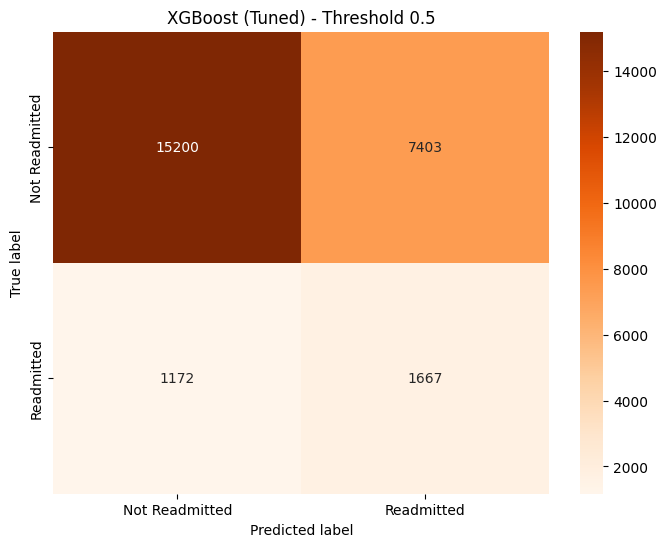

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Same scale_pos_weight you already calculated and validated
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,             # number of random combinations to try
    scoring='roc_auc',     # consistent with your evaluation step
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")

# Evaluate the tuned model on the held-out test set
best_xgb = random_search.best_estimator_
y_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}")

y_pred_tuned = (y_proba_tuned >= 0.5).astype(int)
print(classification_report(y_test, y_pred_tuned))

cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('XGBoost (Tuned) - Threshold 0.5')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## INSIGHT
1. Test ROC-AUC vs. baseline: 0.6861 vs. 0.684 a real but tiny gain (+0.002). Not a meaningful jump.
2. CV score vs. test score: 0.6751 vs. 0.6861 close, test even slightly higher than CV. No overfitting; the model generalizes fine.
3. Recall/precision at threshold 0.5: recall actually dipped slightly, from 0.61 (untuned) to 0.59 (tuned). Precision held flat at 0.18, accuracy ticked up from 0.65 to 0.66.

Tuning didn't break new ground ROC-AUC barely moved and recall actually went the wrong direction. The untuned XGBoost (ROC-AUC 0.684, recall 0.61) and the tuned one (ROC-AUC 0.686, recall 0.59) are functionally tied; neither is clearly better than the other for your stated goal of catching readmissions.

In [ ]:
import pprint
pprint.pprint(random_search.best_params_)

{'colsample_bytree': 0.7,
 'learning_rate': 0.05,
 'max_depth': 5,
 'min_child_weight': 5,
 'n_estimators': 300,
 'subsample': 0.9}


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Narrowed grid: one step above/below/at each best value from RandomizedSearchCV
param_grid_narrow = {
    'n_estimators': [250, 300, 350],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.08],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [3, 5, 7]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_narrow,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

best_xgb_grid = grid_search.best_estimator_
y_proba_grid = best_xgb_grid.predict_proba(X_test)[:, 1]
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_grid):.4f}")

y_pred_grid = (y_proba_grid >= 0.5).astype(int)
print(classification_report(y_test, y_pred_grid))

cm = confusion_matrix(y_test, y_pred_grid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('XGBoost (GridSearchCV, Narrowed) - Threshold 0.5')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


## INSIGHT

Three tuning approaches were tested on XGBoost: default parameters, RandomizedSearchCV (30 candidates), and a GridSearchCV narrowed around the random search's best params (729 candidates, 3,645 fits). Results converged within a tight 0.684 -0.687 ROC-AUC band, with the narrowed grid search achieving the highest score (0.6865) while matching the untuned model's recall (0.61) unlike RandomizedSearchCV, which traded recall (0.59) for a marginal ROC-AUC gain.

The small, consistent improvement across all three approaches (≤0.003 ROC-AUC) indicates the untuned default hyperparameters were already near optimal for this feature set hyperparameter tuning offered diminishing returns compared to the earlier jump from Random Forest to XGBoost (0.653 → 0.684). This suggests the model's performance ceiling is driven primarily by the available features rather than algorithm configuration, reinforcing that further gains are more likely to come from feature engineering than continued tuning.

Final model selected: XGBoost (GridSearchCV tuned) ROC-AUC 0.6865, recall 0.61, precision 0.18.

## STEP 9 FEATURE IMPORTANCE

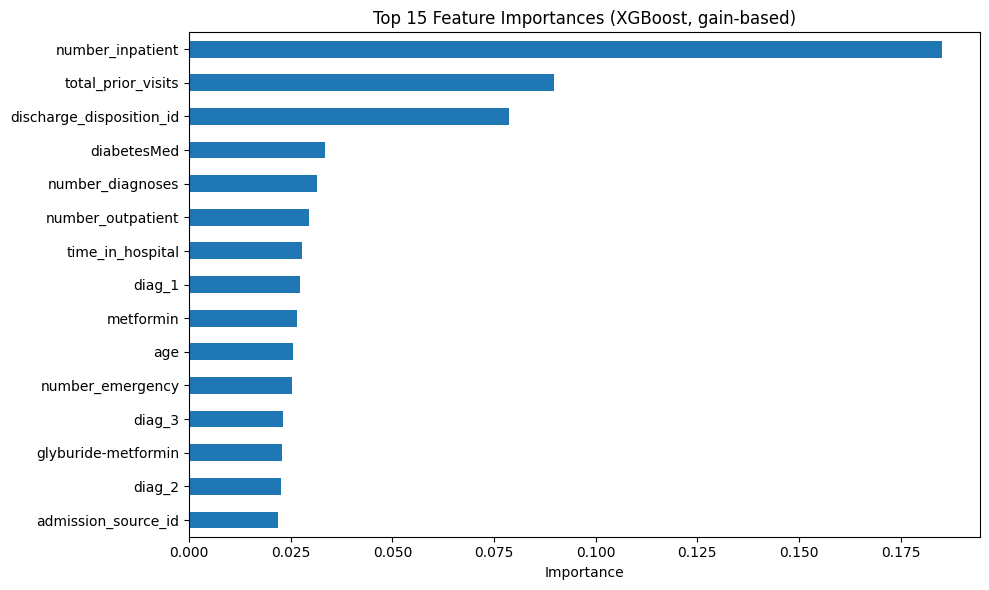

number_inpatient            0.185277
total_prior_visits          0.089795
discharge_disposition_id    0.078663
diabetesMed                 0.033479
number_diagnoses            0.031518
number_outpatient           0.029515
time_in_hospital            0.027690
diag_1                      0.027327
metformin                   0.026545
age                         0.025515
number_emergency            0.025386
diag_3                      0.023035
glyburide-metformin         0.022834
diag_2                      0.022630
admission_source_id         0.021907
dtype: float32


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Raw importance, per encoded column
importances = pd.Series(
    best_xgb_grid.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_n = 15
plt.figure(figsize=(10, 6))
importances.head(top_n).plot(kind='barh')
plt.title('Top 15 Feature Importances (XGBoost, gain-based)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances.head(top_n))

## INSIGHT From Feature Importance

XGBoost's feature importance rankings are dominated by prior healthcare utilization, not demographic or treatment type variables. number_inpatient is the single strongest predictor by a wide margin at 0.185, it's roughly double the importance of the next ranked feature (total_prior_visits, 0.090) and more than six times most other features in the top 15. Three of the top six features (number_inpatient, total_prior_visits, number_outpatient) and number_emergency (11th) all measure how often a patient has previously used the healthcare system together, this utilization history cluster outweighs every individual diagnosis code, medication, or demographic feature in the dataset.
discharge_disposition_id (0.079) is the strongest non utilization signal, suggesting where a patient goes after discharge (e.g., home vs. another care facility) carries real predictive weight plausibly tied to how supported a patient is post discharge. Medication related features (diabetesMed, metformin, glyburide metformin) and diagnosis codes (diag_1/2/3) all rank meaningfully lower, each contributing a relatively small, similar sized share.

Why this matters for the model comparison story: this distribution one dominant feature, a few strong supporting ones, then a long tail of smaller contributors is exactly the kind of narrow but strong signal pattern that explains why XGBoost outperformed Random Forest. Sequential boosting can concentrate on a feature like number_inpatient and refine around it across successive trees, while Random Forest's independently built, averaged trees dilute that same signal across many bootstrap samples. The feature importance results aren't just a list they're evidence for why the model architecture decision in Step 7 mattered.

True one-hot families detected: []
number_inpatient            0.185277
total_prior_visits          0.089795
discharge_disposition_id    0.078663
diabetesMed                 0.033479
number_diagnoses            0.031518
number_outpatient           0.029515
time_in_hospital            0.027690
diag_1                      0.027327
metformin                   0.026545
age                         0.025515
number_emergency            0.025386
diag_3                      0.023035
glyburide-metformin         0.022834
diag_2                      0.022630
admission_source_id         0.021907
dtype: float32


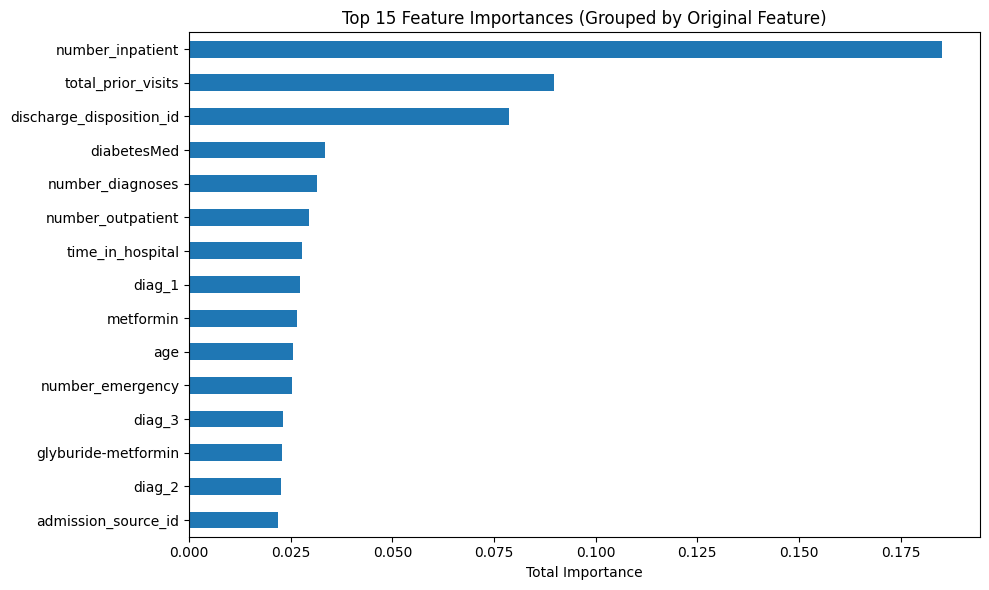

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

importances = pd.Series(best_xgb_grid.feature_importances_, index=X_train.columns)

# Candidate groups by prefix (before the last underscore)
prefix_groups = {}
for col in X_train.columns:
    if '_' in col:
        prefix = col.rsplit('_', 1)[0]
        prefix_groups.setdefault(prefix, []).append(col)

# Keep only groups that are TRUE one-hot families: binary, mutually exclusive per row
true_onehot_groups = {}
standalone_cols = list(X_train.columns)

for prefix, cols in prefix_groups.items():
    if len(cols) < 2:
        continue
    subset = X_train[cols]
    if not subset.isin([0, 1]).all().all():
        continue
    if (subset.sum(axis=1) <= 1).all():
        true_onehot_groups[prefix] = cols
        for c in cols:
            standalone_cols.remove(c)

grouped_importance = {}
for prefix, cols in true_onehot_groups.items():
    grouped_importance[prefix] = importances[cols].sum()
for col in standalone_cols:
    grouped_importance[col] = importances[col]

grouped_importance = pd.Series(grouped_importance).sort_values(ascending=False)

print("True one-hot families detected:", list(true_onehot_groups.keys()))
print(grouped_importance.head(15))

plt.figure(figsize=(10, 6))
grouped_importance.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Grouped by Original Feature)')
plt.xlabel('Total Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### INSIGHT
I can Confirm that "True one hot families detected:" is exactly as expected. The grouped chart and plain chart are identical, which tells me that something useful in its own right: the encoding in Step 4 produced clean, semantically meaningful columns rather than fragmented one-hot dummies. There's nothing to merge because nothing was artificially split in the first place.

A check for one hot encoded feature families (mutually exclusive binary columns sharing a prefix) returned no matches, confirming the dataset's encoding preserved single, semantically coherent columns per feature rather than fragmenting them into dummy variables. The grouped and ungrouped importance rankings are therefore identical the plain XGBoost importance output already reflects each feature's true contribution without correction needed.

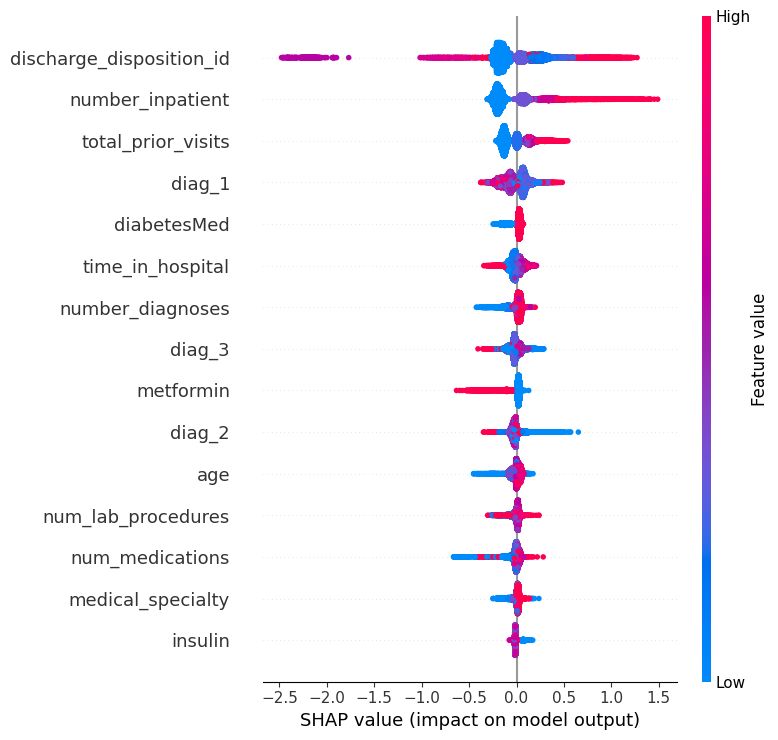

In [ ]:
# !pip install -q shap
import shap

explainer = shap.TreeExplainer(best_xgb_grid)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=15, show=True)

#### INSIGHT SHAP Analysis

SHAP values confirm clear, directional relationships for the model's top numeric features. For number_inpatient, total_prior_visits, and number_diagnoses, high feature values (red) consistently push predictions toward higher readmission risk, while low values (blue) push toward lower risk. This validates the assumption from the plain importance ranking: prior healthcare utilization isn't just correlated with the model's predictions it drives them in the intuitive direction, with more prior visits and more diagnoses translating directly to higher predicted readmission risk.
One important caveat for interpretation: several top features discharge_disposition_id, diag_1, diag_2, diag_3, and admission_source_id are categorical codes stored as numbers, where the numeric value has no inherent order (e.g., a discharge code of "7" isn't "higher" than "3," they simply represent different categories like "discharged home" vs. "transferred to another facility"). SHAP's red/blue color scale implies a numeric ordering that doesn't meaningfully exist for these features. discharge_disposition_id does show a wide SHAP value spread, confirming it has strong influence on predictions overall but that influence comes from which category a patient falls into, not from the code being numerically high or low. Any business insight drawn from this feature should be broken out by category, not described as a "high vs. low" relationship.
Lower ranked features (age, num_lab_procedures, num_medications, medical_specialty, insulin) show SHAP values clustered tightly around zero, confirming they have comparatively little individual influence on predictions consistent with their smaller bars in the importance ranking.


## STEP 10 BUSINESS INSIGHTS & RECOMMENDATIONS

In [ ]:
import pandas as pd

# Map discharge_disposition_id codes to readmission rate
# Uses your original X_train/X_test split labels (y_train, y_test) joined back to discharge codes
discharge_analysis = pd.DataFrame({
    'discharge_disposition_id': pd.concat([X_train['discharge_disposition_id'], X_test['discharge_disposition_id']]),
    'readmitted': pd.concat([y_train, y_test])
})

readmit_by_discharge = (
    discharge_analysis.groupby('discharge_disposition_id')['readmitted']
    .agg(readmission_rate='mean', patient_count='count')
    .sort_values('readmission_rate', ascending=False)
)

# Filter out tiny groups that could give misleading rates (e.g., <30 patients)
readmit_by_discharge_filtered = readmit_by_discharge[readmit_by_discharge['patient_count'] >= 30]

print(readmit_by_discharge_filtered.head(10))

                          readmission_rate  patient_count
discharge_disposition_id                                 
15                                0.444444             63
28                                0.366906            139
22                                0.276969           1993
5                                 0.208615           1184
2                                 0.160714           2128
3                                 0.146625          13954
24                                0.145833             48
7                                 0.144462            623
8                                 0.138889            108
4                                 0.127607            815


In [ ]:
discharge_disposition_map = {
    1: "Discharged to home",
    2: "Discharged/transferred to another short term hospital",
    3: "Discharged/transferred to SNF",
    4: "Discharged/transferred to ICF",
    5: "Discharged/transferred to another type of inpatient care institution",
    6: "Discharged/transferred to home with home health service",
    7: "Left AMA",
    8: "Discharged/transferred to home under care of Home IV provider",
    9: "Admitted as an inpatient to this hospital",
    10: "Neonate discharged to another hospital for neonatal aftercare",
    11: "Expired",
    12: "Still patient or expected to return for outpatient services",
    13: "Hospice / home",
    14: "Hospice / medical facility",
    15: "Discharged/transferred within this institution to Medicare approved swing bed",
    16: "Discharged/transferred/referred another institution for outpatient services",
    17: "Discharged/transferred/referred to this institution for outpatient services",
    18: "NULL",
    19: "Expired at home (Medicaid hospice)",
    20: "Expired in a medical facility (Medicaid hospice)",
    21: "Expired, place unknown (Medicaid hospice)",
    22: "Discharged/transferred to another rehab fac including rehab units of a hospital",
    23: "Discharged/transferred to a long term care hospital",
    24: "Discharged/transferred to a nursing facility certified under Medicaid but not Medicare",
    25: "Not Mapped",
    26: "Unknown/Invalid",
    27: "Discharged/transferred to a federal health care facility",
    28: "Discharged/transferred/referred to a psychiatric hospital",
    29: "Discharged/transferred to a Critical Access Hospital (CAH)",
    30: "Discharged/transferred to another type of health care institution"
}

# Apply to your earlier readmit_by_discharge_filtered table
readmit_by_discharge_filtered = readmit_by_discharge_filtered.copy()
readmit_by_discharge_filtered['description'] = readmit_by_discharge_filtered.index.map(discharge_disposition_map)
print(readmit_by_discharge_filtered[['description', 'readmission_rate', 'patient_count']])

                                                                description  \
discharge_disposition_id                                                      
15                        Discharged/transferred within this institution...   
28                        Discharged/transferred/referred to a psychiatr...   
22                        Discharged/transferred to another rehab fac in...   
5                         Discharged/transferred to another type of inpa...   
2                         Discharged/transferred to another short term h...   
3                                             Discharged/transferred to SNF   
24                        Discharged/transferred to a nursing facility c...   
7                                                                  Left AMA   
8                         Discharged/transferred to home under care of H...   
4                                             Discharged/transferred to ICF   
6                         Discharged/transferred to 

### Project Summary
This project predicted 30 day hospital readmission risk for diabetic patients using the UCI Diabetes 130 US Hospitals dataset. Five modeling approaches were systematically evaluated a Logistic Regression baseline, Random Forest with three imbalance handling techniques, and XGBoost culminating in a tuned XGBoost model as the final selection.
Model Performance, in Practical Terms
The final model achieves a ROC-AUC of 0.6865 and correctly identifies 61% of patients who will be readmitted (recall) at a standard decision threshold, while flagging roughly 30% of all patients as elevated risk. Used as a triage tool, it would catch roughly 6 in 10 readmissions a meaningful improvement over no screening, though precision (18%) means most flagged patients won't actually be readmitted. This model is best suited to directing limited follow up resources toward a higher risk subset, not as a standalone diagnostic.

### Key Risk Drivers

SHAP analysis confirms that prior healthcare utilization is the dominant, directional driver of readmission risk more so than medication regimen, diagnosis codes, or demographics. number_inpatient (prior inpatient stays) is the single strongest predictor, with high values clearly and consistently linked to higher risk. total_prior_visits and number_diagnoses follow the same clean pattern: more prior visits and more diagnoses, more risk.

### Discharge Disposition: A Second, Independent Risk Signal
Readmission rates vary sharply by where a patient is discharged to, and the pattern is both strong and clinically intuitive. Patients discharged home (the majority of the dataset, n≈60,000) have a 9.3% baseline readmission rate. Patients transferred to continued institutional care show substantially elevated risk at the same scale:

Discharge.         Readmission.   Patients
Home (baseline)      9.3%.        60,234       
Skilled N.F          14.7%        13,954
Another STH          16.1%         2,128
Another ICI.         20.9%         1,184
Another RF           27.7%         1,993

KEY NOTE:
N.F = NURSING FACILITY
STH = SHORT TERM HOSPITAL
ICI = INPATIENT CARE INSTITUTION
RF = REHAB FACILITY

That's roughly 1.5x to 3x the baseline rate, consistent across thousands of patients per category. Patients well enough to go home are, unsurprisingly, lower risk than patients sick enough to require continued institutional care. (Note: patients coded as "Expired" show a 0% readmission rate a structural artifact, since death precludes readmission by definition, not a clinical finding, and is excluded from this analysis.)

### Recommendation
Two independent, actionable risk signals emerged from this analysis, available at different points in a patient's care:

1. At discharge planning (immediately available): patients being discharged to a skilled nursing facility, rehab facility, another hospital, or another inpatient institution should be flagged for enhanced discharge planning this signal is known the moment a discharge decision is made, before any model scoring is needed.
2. From patient history (requires record pull): patients with 2+ prior inpatient admissions represent the strongest individual predictor in the model and should be prioritized for follow up a callback within 7 days, medication reconciliation, or a scheduled follow up visit.


Combining both signals discharge destination and utilization history gives care teams a low cost, two factor targeting rule that doesn't require the full model to act on, while the XGBoost model itself can be used for more granular, patient by patient risk scoring where resources allow.

### Limitations
Every model tested converged within a tight 0.60 0.69 ROC-AUC band, regardless of imbalance handling or hyperparameter tuning. This consistency suggests the ceiling is a function of the available features, not the modeling approach. Likely missing signal includes lab trends over time, social determinants of health (housing stability, transportation, caregiver support), and medication adherence none of which are captured in this dataset. Future improvement is more likely to come from richer feature engineering than from further model substitution or tuning.